# CIFAR-10 Image Classification using CNN

## objective
Build a Convolutional Neural Network (CNN) capable of classifying images into predefined categories using the CIFAR_10 dataset

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

In [2]:
print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


In [3]:
(x_train, y_train) , (x_test , y_test) = tf.keras.datasets.cifar10.load_data()

In [4]:
print("Training images: " , x_train.shape)
print("Training labels: " , y_train.shape)
print("Testing images: " , x_test.shape)
print("Testing labels: " , y_test.shape)

Training images:  (50000, 32, 32, 3)
Training labels:  (50000, 1)
Testing images:  (10000, 32, 32, 3)
Testing labels:  (10000, 1)


In [5]:
class_names = [
    "airplanes", "automobiles" , "bird" , "cat" , "deer", "dog" , "frog" , "horse" , "ship" , "truck" ]

In [6]:
print(class_names)

['airplanes', 'automobiles', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


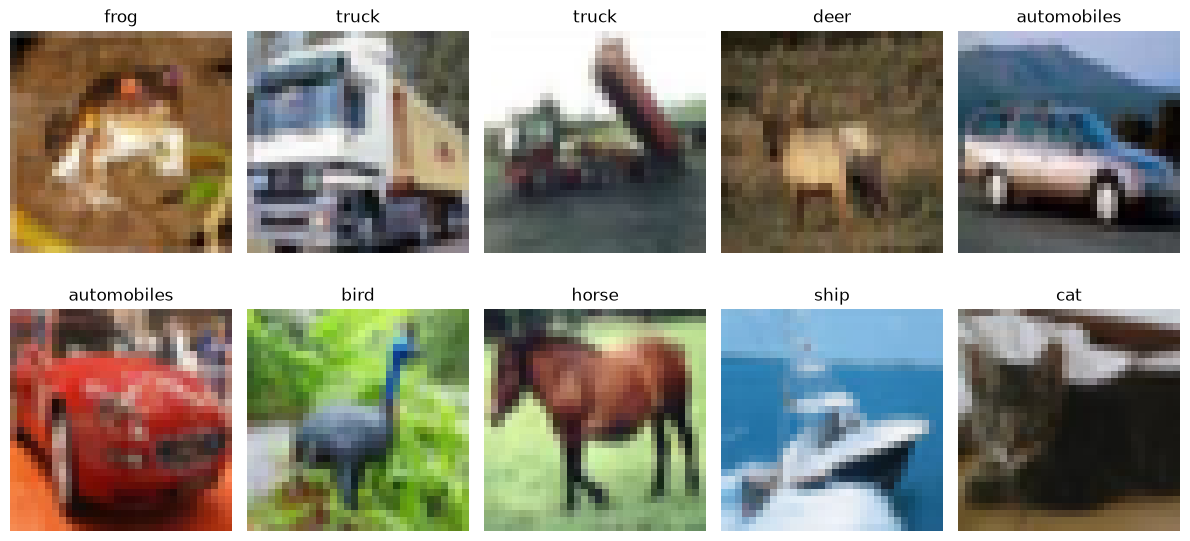

In [7]:
plt.figure(figsize=(12, 6))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [8]:
a = 1
print(a)

1


In [9]:
print("Maximum pixel value:"  , x_train.max())
print("Minimum pixel value:" , x_train.min())

Maximum pixel value: 255
Minimum pixel value: 0


In [10]:
x_train = x_train.astype("float32")/255.0 
x_test = x_test.astype("float32")/255.0

In [11]:
print("Maximum pixel value:"  , x_train.max())
print("Minimum pixel value:" , x_train.min())

Maximum pixel value: 1.0
Minimum pixel value: 0.0


# For validation testing

In [12]:
x_val = x_train[-5000:]
y_val = y_train[-5000:]

x_train = x_train[:-5000]
y_train = y_train[:-5000]

In [13]:
print("Training:", x_train.shape, y_train.shape)
print("Validation:", x_val.shape, y_val.shape)
print("Testing:", x_test.shape, y_test.shape)

Training: (45000, 32, 32, 3) (45000, 1)
Validation: (5000, 32, 32, 3) (5000, 1)
Testing: (10000, 32, 32, 3) (10000, 1)


In [14]:
model = tf.keras.Sequential()

In [15]:
model.add(
    tf.keras.layers.Conv2D(
        32,
        (3,3),
        activation = "relu",
        input_shape = (32,32,3)
    )
        
    )

C:\Users\aleen\OneDrive\Desktop\EncoderX_AI_ML_Task1\venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [16]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 30, 30, 32)          │             896 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 896 (3.50 KB)

 Trainable params: 896 (3.50 KB)

 Non-trainable params: 0 (0.00 B)

In [17]:
model.add(
    tf.keras.layers.MaxPooling2D(
        pool_size=(2,2)
    )
    
        
    )

In [18]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 30, 30, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 15, 15, 32)          │               0 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 896 (3.50 KB)

 Trainable params: 896 (3.50 KB)

 Non-trainable params: 0 (0.00 B)

In [19]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 30, 30, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 15, 15, 32)          │               0 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 896 (3.50 KB)

 Trainable params: 896 (3.50 KB)

 Non-trainable params: 0 (0.00 B)

In [20]:
model.add(
    tf.keras.layers.Conv2D(
        64,
        (3,3),
        activation = "relu",
    )
        
    )

In [21]:
model.add(
    tf.keras.layers.MaxPooling2D(
        pool_size=(2,2)
    )
    
        
    )

In [22]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 30, 30, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 15, 15, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 13, 13, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 6, 6, 64)            │               0 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 19,392 (75.75 KB)

 Trainable params: 19,392 (75.75 KB)

 Non-trainable params: 0 (0.00 B)

In [23]:
model.add(
    tf.keras.layers.Flatten()
)

In [24]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 30, 30, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 15, 15, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 13, 13, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 6, 6, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 2304)                │               0 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 19,392 (75.75 KB)

 Trainable params: 19,392 (75.75 KB)

 Non-trainable params: 0 (0.00 B)

In [25]:
model.add(
    tf.keras.layers.Dense(
        128,
        activation = "relu"
    )
)

In [26]:
model.add(
    tf.keras.layers.Dropout(0.5)
)

In [27]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 30, 30, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 15, 15, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 13, 13, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 6, 6, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 2304)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         295,040 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 314,432 (1.20 MB)

 Trainable params: 314,432 (1.20 MB)

 Non-trainable params: 0 (0.00 B)

In [28]:
model.add(
    tf.keras.layers.Dense(
        10,
        activation = "softmax"
    )
)

In [29]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 30, 30, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 15, 15, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 13, 13, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 6, 6, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 2304)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         295,040 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 315,722 (1.20 MB)

 Trainable params: 315,722 (1.20 MB)

 Non-trainable params: 0 (0.00 B)

In [30]:
model.compile()

In [31]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [32]:
history = model.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=64,
    validation_data = (x_val,y_val)
)

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 13s 19ms/step - accuracy: 0.6416 - loss: 1.0217 - val_accuracy: 0.6672 - val_loss: 0.9274
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 13s 19ms/step - accuracy: 0.6601 - loss: 0.9756 - val_accuracy: 0.6862 - val_loss: 0.8990
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 13s 18ms/step - accuracy: 0.6744 - loss: 0.9296 - val_accuracy: 0.6978 - val_loss: 0.8910
Epoch 9/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 13s 19ms/step - accuracy: 0.6826 - loss: 0.8989 - val_accuracy: 0.7016 - val_loss: 0.8665
Epoch 10/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 13s 19ms/step - accuracy: 0.6978 - loss: 0.8626 - val_accuracy: 0.6996 - val_loss: 0.8570


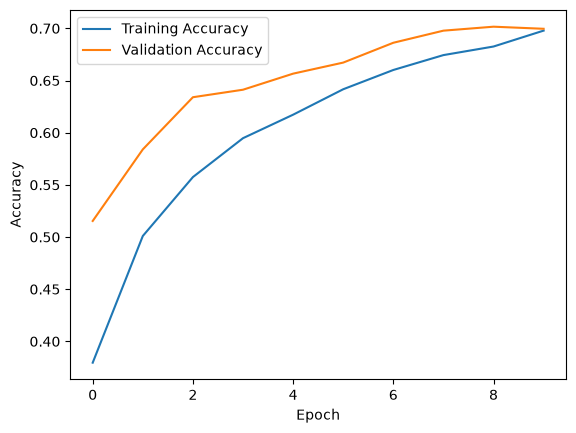

In [33]:
import matplotlib.pyplot as plt

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

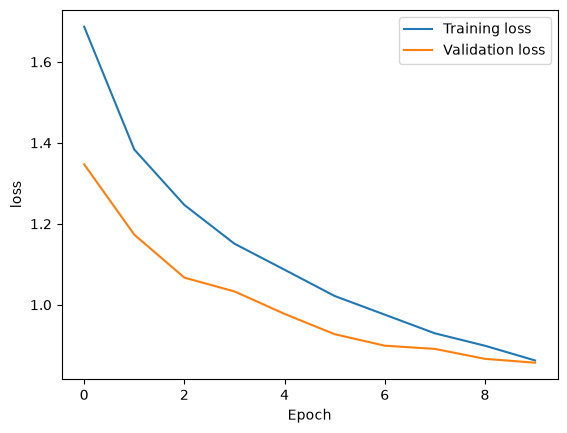

In [34]:
import matplotlib.pyplot as plt

plt.plot(history.history["loss"], label="Training loss")
plt.plot(history.history["val_loss"], label="Validation loss")

plt.xlabel("Epoch")
plt.ylabel("loss")
plt.legend()
plt.show()

In [35]:
test_loss, test_accuracy = model.evaluate(
    x_test,
    y_test,
    batch_size = 64
)

157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.6969 - loss: 0.8824


In [36]:
print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

Test Loss: 0.88241046667099
Test Accuracy: 0.6969000101089478


In [37]:
y_pred = model.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


In [38]:
y_pred_classes = np.argmax(y_pred, axis=1)

In [39]:
print(y_pred_classes[:10])

[3 1 8 0 6 6 1 6 3 1]


In [40]:
y_pred_classes = np.argmax(y_pred, axis=1)

print(y_pred_classes[:10])

[3 1 8 0 6 6 1 6 3 1]


In [44]:
from sklearn.metrics import confusion_matrix

In [45]:
cm = confusion_matrix(
    y_test.flatten(),
    y_pred_classes
)

print(cm)

[[829  13  29  24  15   8  10  14  25  33]
 [ 33 806   6   8   5   9  11   6  17  99]
 [ 77   4 491  73 114 133  61  30  12   5]
 [ 28   8  52 481  53 258  68  29  12  11]
 [ 25   4  51  85 645  62  45  73   9   1]
 [ 15   2  32 144  48 689  20  36   5   9]
 [  8   4  37  62  65  44 762   7   3   8]
 [ 17   3  19  41  49 108   4 743   3  13]
 [141  42  13  14   4   9   6   8 728  35]
 [ 38  84   6  19  10  10   6  18  14 795]]


In [46]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test.flatten(),
        y_pred_classes,
        target_names=class_names
    )
)

              precision    recall  f1-score   support

   airplanes       0.68      0.83      0.75      1000
 automobiles       0.83      0.81      0.82      1000
        bird       0.67      0.49      0.57      1000
         cat       0.51      0.48      0.49      1000
        deer       0.64      0.65      0.64      1000
         dog       0.52      0.69      0.59      1000
        frog       0.77      0.76      0.76      1000
       horse       0.77      0.74      0.76      1000
        ship       0.88      0.73      0.80      1000
       truck       0.79      0.80      0.79      1000

    accuracy                           0.70     10000
   macro avg       0.71      0.70      0.70     10000
weighted avg       0.71      0.70      0.70     10000



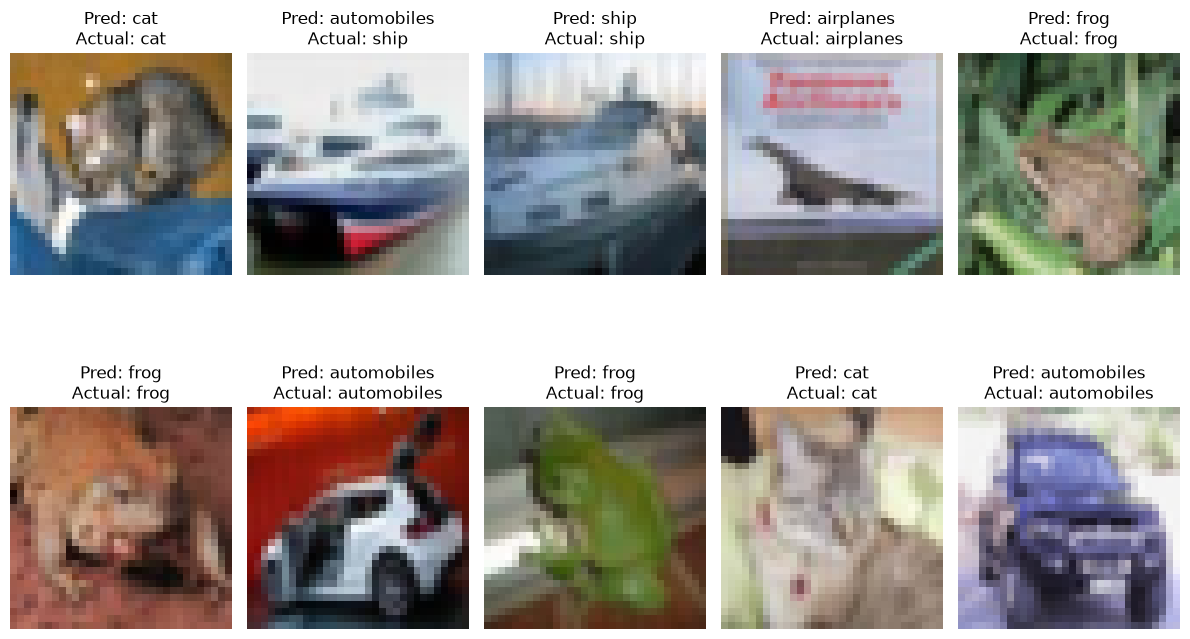

In [48]:
plt.figure(figsize=(12, 8))

for i in range(10):
    plt.subplot(2, 5, i + 1)

    plt.imshow(x_test[i])

    predicted_label = class_names[y_pred_classes[i]]
    actual_label = class_names[y_test[i][0]]

    plt.title(
        f"Pred: {predicted_label}\nActual: {actual_label}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

In [49]:
model.save("cifar10_cnn_model.keras")

In [50]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 30, 30, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 15, 15, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 13, 13, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 6, 6, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 2304)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         295,040 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 947,168 (3.61 MB)

 Trainable params: 315,722 (1.20 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 631,446 (2.41 MB)

## Conclusion

A Convolutional Neural Network (CNN) was developed and trained on the CIFAR-10 dataset containing 10 image classes. The dataset was divided into training, validation, and test sets. The model used convolutional layers for feature extraction, max pooling for spatial reduction, a fully connected layer for classification, and dropout to help reduce overfitting.

The model achieved a test accuracy of approximately 66.56%. The confusion matrix and classification report were used to evaluate the model's performance across individual classes. The results show that the model learned useful visual features, although some classes were more difficult to distinguish from one another. In particular, the confusion matrix showed noticeable confusion between visually similar classes such as cats and dogs and between automobiles and trucks.